# Recurrent Neural Network (RNN) Model

## 1. Imports and configuration

In [ ]:
import os
import random
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

import tensorflow as tf
from tensorflow.keras import layers, callbacks, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

sns.set_theme(style="whitegrid")

DATA_DIR = Path("datasets")
RESULTS_DIR = Path("results")
MODEL_DIR = Path("models")
RESULTS_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

MAX_TOKENS = 30000
MAX_LEN = 256
EMBEDDING_DIM = 128
BATCH_SIZE = 64
EPOCHS = 8
THRESHOLD = 0.50

## 2. Load train/test data and create validation split

In [ ]:
train_df = pd.read_csv(DATA_DIR / "train_hotel_reviews.csv")
test_df = pd.read_csv(DATA_DIR / "test_hotel_reviews.csv")

required_cols = {"review_text", "sentiment"}
missing = required_cols - set(train_df.columns)
if missing:
    raise ValueError(f"Missing required columns in training data: {missing}")

# Some TripAdvisor-derived text contains private-use Unicode characters such as \uf0d8.
# These can break TensorFlow/Keras logging or model saving on Windows cp1252 systems.
PRIVATE_USE_RE = re.compile(r"[\uE000-\uF8FF]")
CONTROL_RE = re.compile(r"[\x00-\x08\x0B\x0C\x0E-\x1F\x7F-\x9F]")

def clean_for_modeling(value):
    if pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKC", str(value))
    text = PRIVATE_USE_RE.sub(" ", text)
    text = CONTROL_RE.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["review_text"] = train_df["review_text"].apply(clean_for_modeling)
test_df["review_text"] = test_df["review_text"].apply(clean_for_modeling)

remaining_private_chars = (
    train_df["review_text"].str.contains(PRIVATE_USE_RE, regex=True).sum()
    + test_df["review_text"].str.contains(PRIVATE_USE_RE, regex=True).sum()
)
print("Remaining private-use Unicode records after cleaning:", int(remaining_private_chars))

train_part, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=SEED,
    stratify=train_df["sentiment"],
)

X_train = train_part["review_text"].values
y_train = train_part["sentiment"].astype(int).values

X_val = val_df["review_text"].values
y_val = val_df["sentiment"].astype(int).values

X_test = test_df["review_text"].values
y_test = test_df["sentiment"].astype(int).values

print("Train shape:", train_part.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("Train class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index().round(3))

Remaining private-use Unicode records after cleaning: 0
Train shape: (54482, 9)
Validation shape: (9615, 9)
Test shape: (16025, 9)
Train class distribution:
0    0.286
1    0.714
Name: proportion, dtype: float64


## 3. Build TensorFlow input pipeline

In [ ]:
def make_text_dataset(texts, labels, batch_size=BATCH_SIZE, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(texts), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_text_dataset(X_train, y_train, shuffle=True)
val_ds = make_text_dataset(X_val, y_val)
test_ds = make_text_dataset(X_test, y_test)

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LEN,
    standardize="lower_and_strip_punctuation",
)

# Adapt only on the training text to avoid leaking validation/test information.
vectorizer.adapt(tf.data.Dataset.from_tensor_slices(X_train).batch(BATCH_SIZE))

print("Vocabulary size used by RNN:", len(vectorizer.get_vocabulary()))

Vocabulary size used by RNN: 30000


## 4. Define the RNN model

In [ ]:
def build_rnn_model():
    text_input = layers.Input(shape=(1,), dtype=tf.string, name="review_text")
    x = vectorizer(text_input)
    x = layers.Embedding(
        input_dim=MAX_TOKENS,
        output_dim=EMBEDDING_DIM,
        mask_zero=True,
        name="token_embedding",
    )(x)

    # SimpleRNN is the basic recurrent baseline. The BiLSTM notebook provides
    # the stronger gated recurrent model for comparison.
    x = layers.SimpleRNN(64, return_sequences=False, name="simple_rnn_encoder")(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    output = layers.Dense(1, activation="sigmoid", name="sentiment_probability")(x)

    model = models.Model(inputs=text_input, outputs=output, name="rnn_hotel_sentiment")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )
    return model

rnn_model = build_rnn_model()
rnn_model.summary()

Model: "rnn_hotel_sentiment"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ review_text         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 256)       │          0 │ review_text[0][0] │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, 256, 128)  │  3,840,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 256)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_encoder  │ (None, 64)        │     12,352 │ token_embedding[… │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ simple_rnn_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_probabil… │ (None, 1)         │         65 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,856,577 (14.71 MB)

 Trainable params: 3,856,577 (14.71 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the RNN model

In [ ]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(cls): float(weight) for cls, weight in zip(classes, weights)}
print("Class weights:", class_weight)

class ASCIILogger(callbacks.Callback):
    """Print epoch summaries using plain ASCII to avoid Windows cp1252 Unicode errors."""
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        parts = [f"epoch={epoch + 1}"]
        for key in [
            "loss", "accuracy", "precision", "recall", "auc",
            "val_loss", "val_accuracy", "val_precision", "val_recall", "val_auc"
        ]:
            if key in logs:
                parts.append(f"{key}={logs[key]:.4f}")
        print(" | ".join(parts))

training_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=2,
        restore_best_weights=True,
    ),
    ASCIILogger(),
]

history = rnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=training_callbacks,
    verbose=0,
)

history_df = pd.DataFrame(history.history)
history_df.to_csv(RESULTS_DIR / "rnn_training_history.csv", index=False)

# Save weights only. Saving the full Keras model can fail on Windows if the
# TextVectorization vocabulary contains unsupported Unicode characters.
rnn_model.save_weights(str(MODEL_DIR / "rnn_hotel_sentiment.weights.h5"))
print("Saved RNN weights to:", MODEL_DIR / "rnn_hotel_sentiment.weights.h5")

history_df.tail()

Class weights: {0: 1.7475622273543752, 1: 0.7003908057798118}


c:\Users\mthlu\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


epoch=1 | loss=0.6889 | accuracy=0.5454 | precision=0.7475 | recall=0.5486 | auc=0.5650 | val_loss=0.6258 | val_accuracy=0.6469 | val_precision=0.8183 | val_recall=0.6496 | val_auc=0.7052
epoch=2 | loss=0.6616 | accuracy=0.6383 | precision=0.7792 | recall=0.6884 | auc=0.6421 | val_loss=0.6214 | val_accuracy=0.6464 | val_precision=0.7869 | val_recall=0.6920 | val_auc=0.6782
epoch=3 | loss=0.6196 | accuracy=0.6323 | precision=0.8323 | recall=0.6073 | auc=0.7118 | val_loss=0.6788 | val_accuracy=0.5196 | val_precision=0.8266 | val_recall=0.4139 | val_auc=0.6386
Saved RNN weights to: models\rnn_hotel_sentiment.weights.h5


,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
0,0.545410,0.565045,0.688947,0.747451,0.548568,0.646906,0.705160,0.625848,0.818315,0.649621
1,0.638321,0.642091,0.661635,0.779226,0.688410,0.646386,0.678156,0.621355,0.786945,0.692016
2,0.632282,0.711750,0.619638,0.832253,0.607317,0.519605,0.638564,0.678798,0.826593,0.413899


## 6. Plot RNN training curves

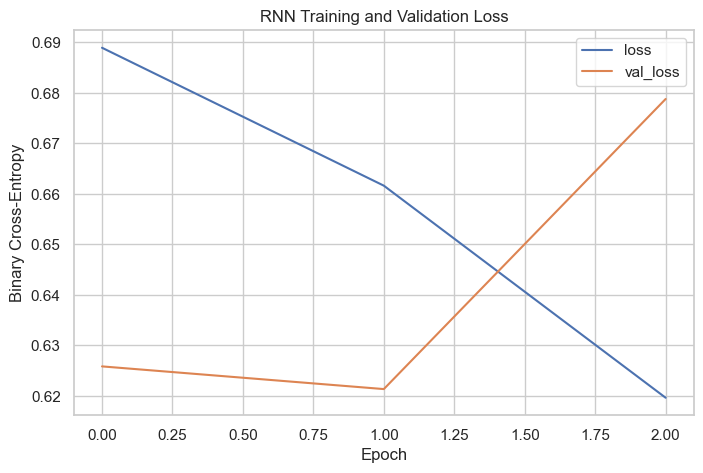

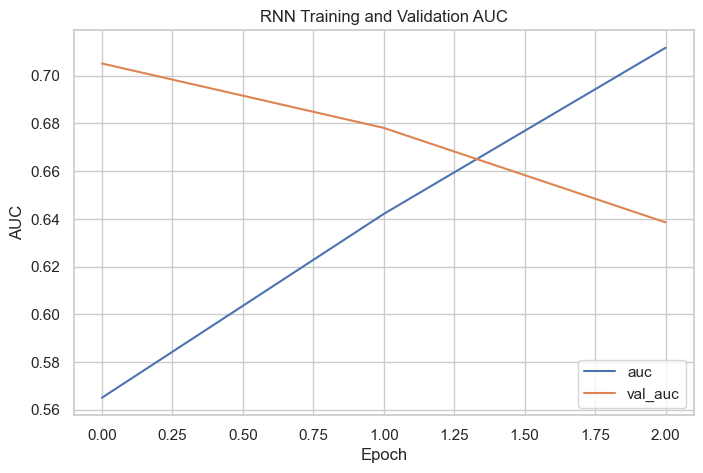

In [ ]:
history_df[["loss", "val_loss"]].plot(figsize=(8, 5))
plt.title("RNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.show()

history_df[["auc", "val_auc"]].plot(figsize=(8, 5))
plt.title("RNN Training and Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.show()

## 7. Evaluate the RNN on the held-out test set

Model        RNN Text Classifier
Accuracy                0.646303
Precision               0.817352
Recall                  0.649738
F1                       0.72397
ROC_AUC                 0.704959
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.42      0.64      0.51      4585
           1       0.82      0.65      0.72     11440

    accuracy                           0.65     16025
   macro avg       0.62      0.64      0.62     16025
weighted avg       0.70      0.65      0.66     16025



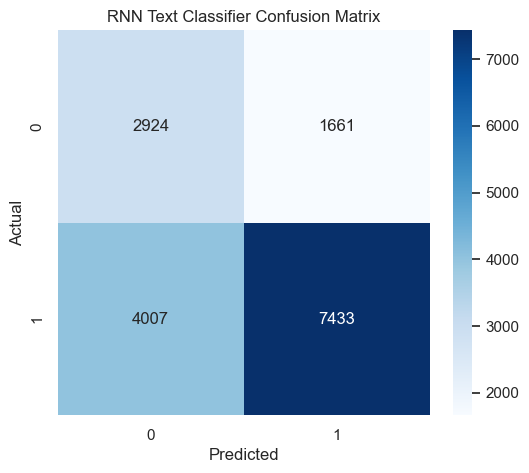

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,RNN Text Classifier,0.6463,0.8174,0.6497,0.724,0.705


In [ ]:
def evaluate_binary_classifier(model, dataset, y_true, model_name, threshold=THRESHOLD):
    y_prob = model.predict(dataset, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan,
    }

    print(pd.Series(metrics))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return metrics, y_prob, y_pred

rnn_metrics, rnn_probs, rnn_preds = evaluate_binary_classifier(
    rnn_model,
    test_ds,
    y_test,
    model_name="RNN Text Classifier",
)

rnn_results = pd.DataFrame([rnn_metrics])
rnn_results.to_csv(RESULTS_DIR / "rnn_results.csv", index=False)
rnn_results.round(4)

## 8. Save RNN predictions for later comparison/error analysis

In [ ]:
predictions_df = test_df[["review_text", "sentiment"]].copy()
predictions_df["rnn_probability_positive"] = rnn_probs
predictions_df["rnn_prediction"] = rnn_preds
predictions_df.to_csv(RESULTS_DIR / "rnn_test_predictions.csv", index=False)

print("Saved RNN weights, metrics, training history, and test predictions.")

Saved RNN weights, metrics, training history, and test predictions.
